<a href="https://colab.research.google.com/github/moonchanglee/NaturalLangProcessing/blob/main/1_LangGraph_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 환경 설정

In [ ]:
!pip install python-dotenv
!pip install langchain
!pip install langchain-core
!pip install langchain-community
!pip install langchain-openai
!pip install langgraph

### **옵션1. 직접 KEY 값을 환경 변수에 저장하는 방식**

In [ ]:
import os, getpass

def _set_env(var: str):
    os.environ[var] = getpass.getpass(f"{var}: ")

In [ ]:
_set_env("OPENAI_API_KEY")

**Tavily API 사용하기**

Tavily는 LLM과 web 검색을 연동하기 위한 API입니다. 역시 API를 사용하기 위해 Key값을 받아와야 합니다.

[Tavily.com](https://app.tavily.com/)에 접속해 가입하고, API key를 생성합시다.

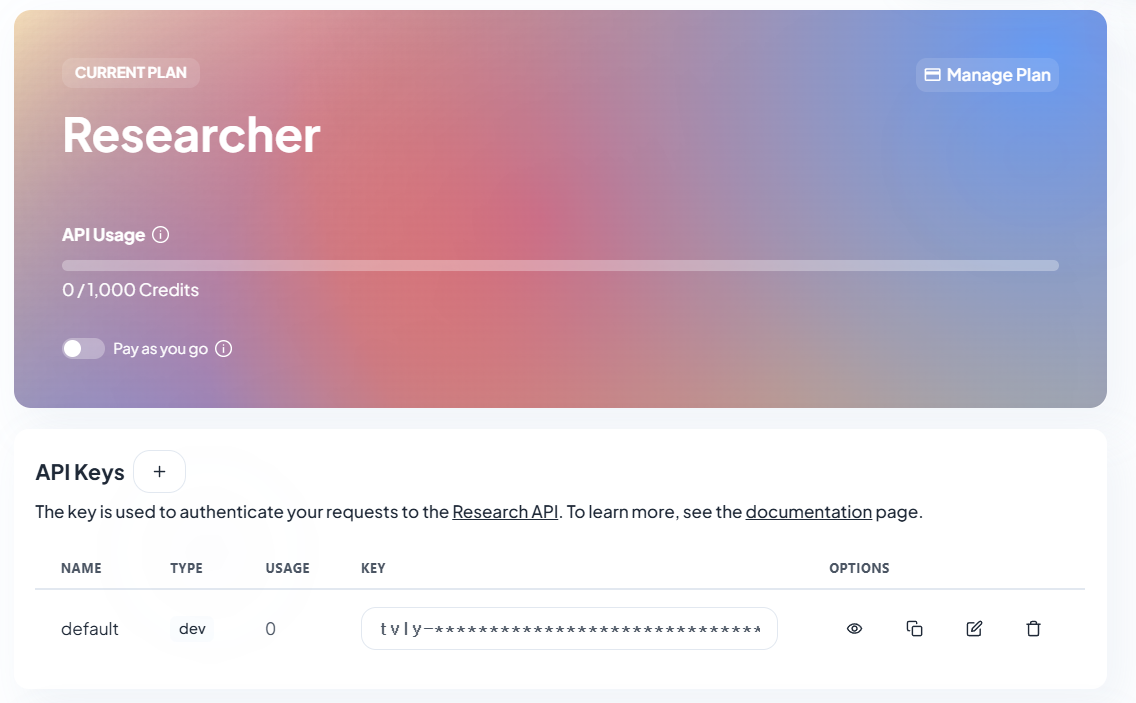

In [ ]:
_set_env("TAVILY_API_KEY")

### **옵션 2. .env 파일을 만들어서 KEY 값을 관리하는 방식**

**LangSmith**

LLM 애플리케이션에는 LLM 호출을 여러 번 호출하는 여러 단계가 포함됩니다. 이러한 애플리케이션이 점점 더 복잡해짐에 따라 체인이 예상보다 느리거나 에이전트 내부의 루핑, 오류를 검사할 수 있는 것이 중요해집니다. 이를 수행하는 가장 좋은 방법은 [LangSmith](https://smith.langchain.com/)를 사용하는 것입니다 .

위 링크로 들어가 Set up tracing을 통해 API Key를 생성하고 monitoring을 시작합니다.

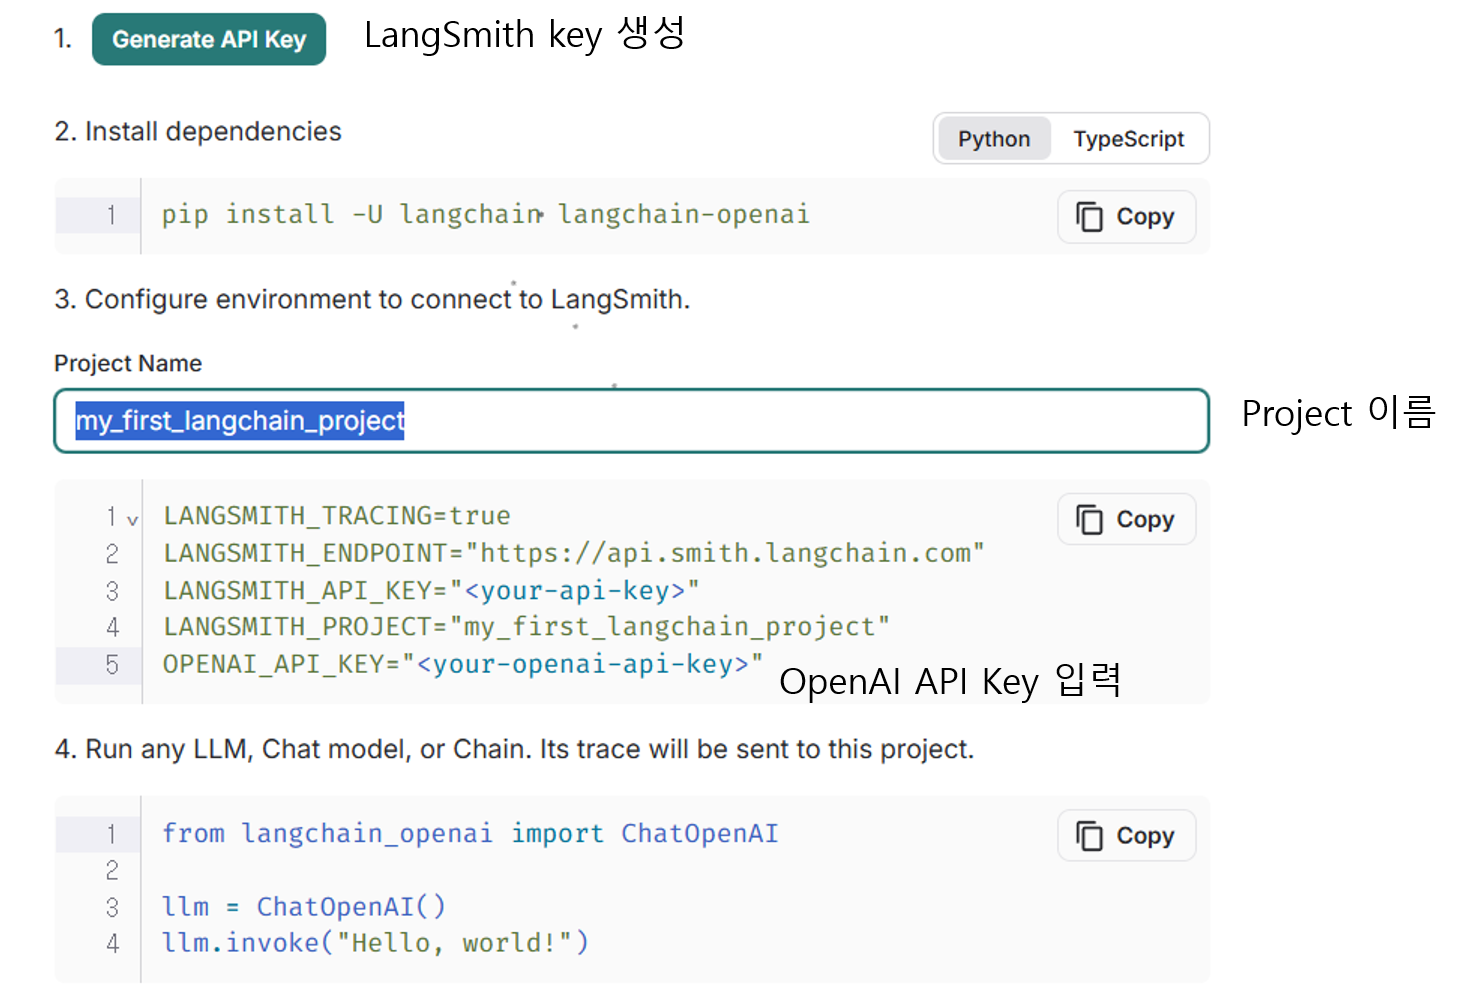

현재 경로에 .env 파일을 만들고, OPENAI KEY와 LANGSMITH KEY 정보를 함께 넣어줍니다.

형식은 다음과 같습니다...



.env의 형식은 다음과 같습니다 (아래를 복사하지 마시고, 본인 계정의 LangSmith 정보를 가져와야 합니다.)
```
LANGSMITH_TRACING=true
LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
LANGSMITH_API_KEY="lsv2_pt_31dfbd8d34e999df7a0e8715c0b5d_dsafareggfd"
LANGSMITH_PROJECT="my_first_langchain_project"
OPENAI_API_KEY="sk-proj-bIjXoUoqB_jXE1R4tIZDq_wfdsgrefdbgfdnEdQH8rMsRdoCixsgQfYP4ngxMrpRFkIEBh97BtR8T3BlbkFJxigmCGyusLAihd9aB0s8sShLvgzf3uQAliroXG39giX5_GVS3jW2jl263LYydBxq4CQ6TzQY8A"
```





**Tavily API 사용하기**

Tavily는 LLM과 web 검색을 연동하기 위한 API입니다. 역시 API를 사용하기 위해 Key값을 받아와야 합니다.

[Tavily.com](https://app.tavily.com/)에 접속해 가입하고, API key를 생성합시다.

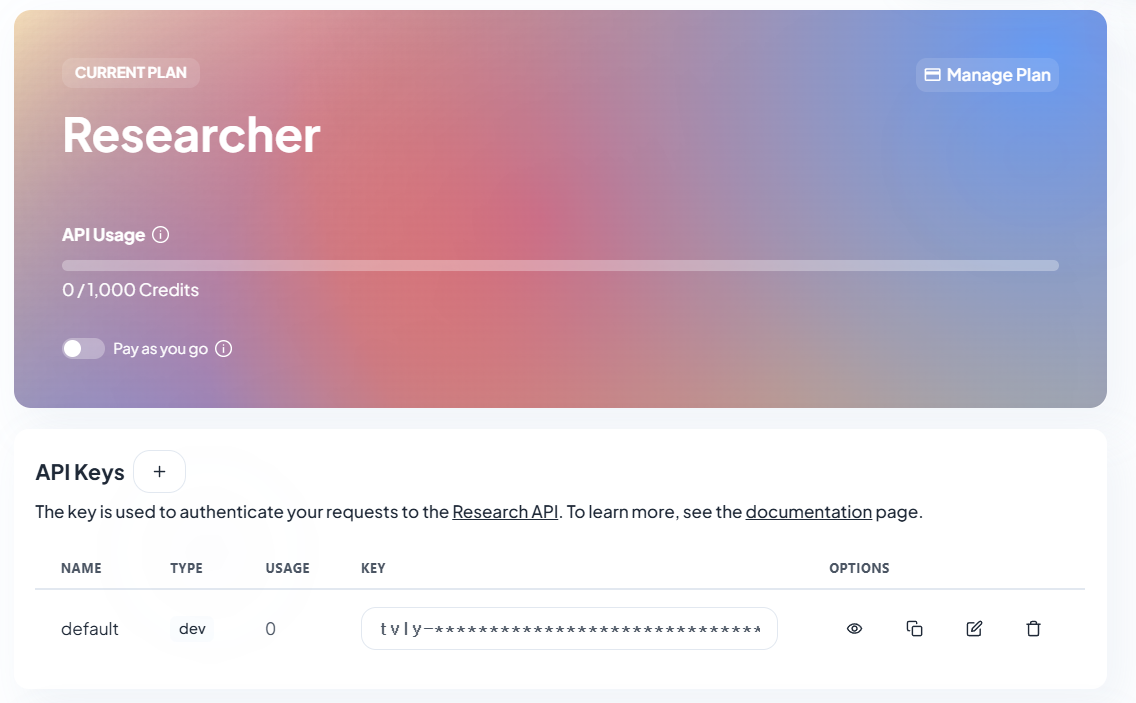

Tavily API KEY를 .env에 추가합니다.

TAVILY_API_KEY="YOUR TAVILY API KEY"

```
LANGSMITH_TRACING=true
LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
LANGSMITH_API_KEY="lsv2_pt_31dfbd8d34e999df7a0e8715c0b5d_dsafareggfd"
LANGSMITH_PROJECT="my_first_langchain_project"
OPENAI_API_KEY="sk-proj-bIjXoUoqB_jXE1R4tIZDq_wfdsgrefdbgfdnEdQH8rMsRdoCixsgQfYP4ngxMrpRFkIEBh97BtR8T3BlbkFJxigmCGyusLAihd9aB0s8sShLvgzf3uQAliroXG39giX5_GVS3jW2jl263LYydBxq4CQ6TzQY8A"
TAVILY_API_KEY="your tavily api key"
```

API KEY 를 설정합니다. 현재 경로(Colab에서는 /content 폴더 아래)에 .env 파일을 업로드합니다.

In [ ]:
# API 키를 환경변수로 관리하기 위한 설정 파일
import os
from dotenv import load_dotenv

# API KEY 정보를 로드합니다. 파일 이름은 앞에 comma가 있는 ".env" 파일여야 합니다!
load_dotenv(override=True)
print(f"[API KEY]\n{os.environ['OPENAI_API_KEY']}")
print(f"[API KEY]\n{os.environ['TAVILY_API_KEY']}")

# LangChain llm 생성

LangChain은 LLM(대형 언어 모델)을 활용한 애플리케이션을 쉽게 개발할 수 있도록 돕는 프레임워크입니다.
LangChain을 사용하면 프롬프트 관리, 메모리 유지, 외부 데이터 연동, 체인(chain) 구성, 에이전트 실행 등을 효율적으로 처리할 수 있습니다.

LangGraph는 LangChain을 기반으로 설계된 그래프 기반 AI 워크플로우 프레임워크입니다. LangGraph의 그래프 내 LangChain의 언어모델 객체를 만들어 사용할 것 입니다.


LangChain llm 객체는 다음과 같이 생성합니다.

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI()
llm.invoke("안녕하세요? 당신은 어떤 모델인가요?")

- model_name : 사용할 llm 모델 명칭
- temperature : 낮을 수록 일관되고 높을 수록 무작위적이고 창의적이 됩니다.

In [ ]:
from langchain_openai import ChatOpenAI

# 객체 생성
llm = ChatOpenAI(
    temperature=0.1,  # 창의성 (0.0 ~ 2.0)
    model_name="gpt-4o-mini",  # 모델명
)
llm.invoke("안녕하세요? 당신은 어떤 모델인가요?")

우리가 사용하는 ChatLLM은 대화형 데이터를 처리하기 위해 SystemMessage, HumanMessage, AIMessage, ToolMessage 객체를 사용하여 [메시지](https://python.langchain.com/docs/concepts/messages/)를 정의합니다.

In [ ]:
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage

messages = [
    SystemMessage("당신은 오직 한국어로 답변하는 친절한 AI입니다. 간결하게 답변합니다."),
    HumanMessage("Explain RAG(Retrieval-Augmented Generation.)"),
]

llm.invoke(messages)

그 외 아래와 같은 방법으로도 대화형 프롬프팅(Chat prompting)이 가능합니다.

In [ ]:
llm.invoke("안녕하세요!")

In [ ]:
llm.invoke([{"role": "system", "content": "당신은 오직 한국어로 답변하는 친절한 AI입니다. 간결하게 답변합니다."},
            {"role": "user", "content": "Explain RAG(Retrieval-Augmented Generation.)"}])

 SystemMessage, HumanMessage, AIMessage, ToolMessage와 같은 메시지 객체를 사용하는 것을 권장합니다. 우리는 LangChain에서 상용과 오픈소스를 포함한 매우 다양한 LLM 제품들을 연결해 사용할 수 있습니다. 각 모델에 따라 발화자를 부르는 명칭이 다양할 수 있습니다. 최적의 성능과 오류 확률을 낮추기 위한 인터페이스의 역할을 합니다.

LLM에는 자체 상태(메모리) 개념이 없습니다. 예를 들어, 후속 질문을 하는 경우:

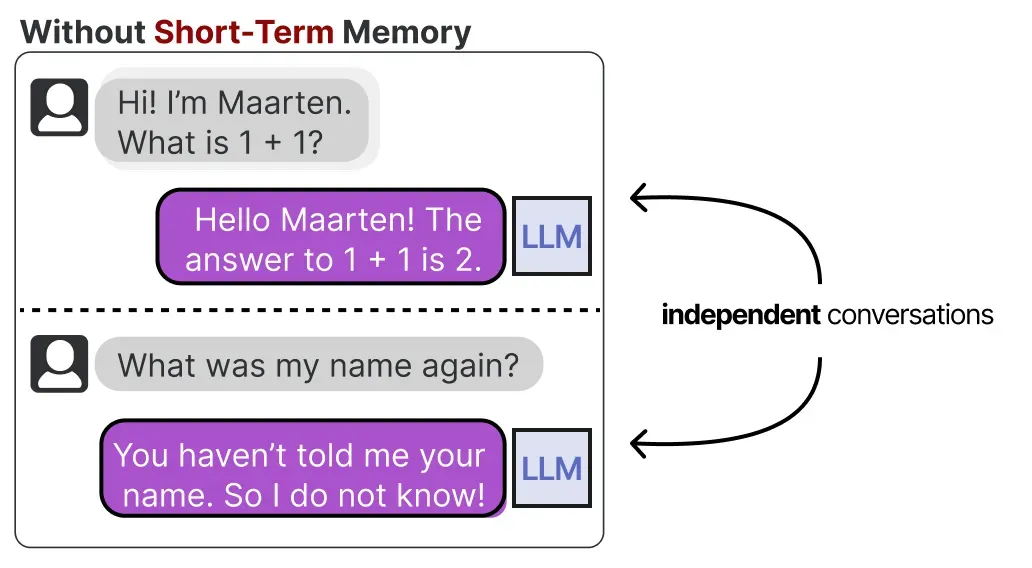

In [ ]:
llm.invoke([HumanMessage(content="내 이름은 티니핑!")]).content

In [ ]:
llm.invoke([HumanMessage(content="내 이름이 뭐게?")]).content

In [ ]:
llm.invoke(
    [
        HumanMessage(content="안녕, 내 이름은 티니핑이라고 해!"),
        AIMessage(content="반가워요, 오늘 어떻게 도와드릴까요?"),
        HumanMessage(content="내 이름이 뭐라고 했지?")
    ]
)


# Prompt Engineering

간단한 프롬프트 엔지니어링으로 워밍업을 해보겠습니다.

프롬프트 엔지니어링(Prompt Engineering)은 대규모 언어 모델(LLM, Large Language Model)의 성능을 최적화하기 위해 입력 문장을 전략적으로 설계하는 과정입니다. 이는 단순히 모델에게 질문을 던지는 것이 아니라, 원하는 결과를 얻기 위해 적절한 형식과 구조를 갖춘 입력을 구성하는 것을 의미합니다.

In [ ]:
from IPython.display import Markdown, display

### 1.1 Text Summarization

In [ ]:
prompt = """항생제는 세균 감염을 치료하는 데 사용되는 약물입니다.
세균을 죽이거나 증식을 막아 신체의 면역 체계가 감염을 퇴치할 수 있도록 돕습니다.
항생제는 일반적으로 알약, 캡슐, 액체 용액 형태로 경구 복용하거나, 경우에 따라 정맥 주사로 투여됩니다.
항생제는 바이러스 감염에 효과가 없으며, 부적절한 사용은 항생제 내성을 유발할 수 있습니다.

위 내용을 한 문장으로 요약하세요:"""

try:
    response = llm.invoke(prompt)
    display(Markdown(response.content))
except Exception as e:
    print(f"오류 발생: {e}")

### 1.2 Question Answering

In [ ]:
prompt = """다음 문맥에 기반하여 질문에 답하세요. 답변은 짧고 간결하게 작성하세요. 확신이 없으면 "확실하지 않음"이라고 답변하세요.

문맥: 테플리주맙(Teplizumab)은 뉴저지의 제약회사인 오쏘 제약(Ortho Pharmaceutical)에서 개발되었습니다. 연구진은 항체의 초기 버전인 OKT3을 생성했습니다. 원래 쥐에서 얻어진 이 분자는 T 세포 표면에 결합하여 세포 살해 능력을 제한할 수 있었습니다. 1986년에 이 분자는 신장 이식 후 장기 거부 반응을 예방하기 위해 승인되었으며, 인간에게 사용이 허가된 최초의 치료용 항체로 기록되었습니다.

질문: OKT3은 원래 무엇에서 얻어졌나요?

답변:"""

try:
    response = llm.invoke(prompt)
    print("요약된 내용:", response.content)
except Exception as e:
    print(f"오류 발생: {e}")

Context obtained from here: https://www.nature.com/articles/d41586-023-00400-x

### 1.3 Text Classification

In [ ]:
prompt1 = """감정 분석 : 텍스트의 감정을 중립, 부정, 긍정 중 하나로 분류하세요.

텍스트: 음식이 그럭저럭 괜찮았던 것 같아요.

감정:"""

prompt2 = """감정 분석 : 텍스트의 감정을 중립, 부정, 긍정 중 하나로 분류하세요.

텍스트: 음식이 감칠맛을 잘 살렸고, 전체적으로 만족했었어요!

감정:"""

prompt3 = """감정 분석 : 텍스트의 감정을 중립, 부정, 긍정 중 하나로 분류하세요.

텍스트: 다시는 안 갈 것 같아요...

감정:"""


for prompt in [prompt1, prompt2, prompt3]:

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    # OpenAI 응답 생성 함수 호출
    try:
        response = llm.invoke(prompt)
        print(response.content)
    except Exception as e:
        print(f"오류 발생: {e}")

Exercise: 프롬프트를 수정하여 모델이 선택한 답변에 대한 설명을 제공하도록 설정해봅시다.

In [ ]:
prompt = """감정 분석 : 텍스트의 감정을 [중립, 부정, 긍정] 중 하나의 카테고리로 분류합니다. 선택한 답변에 대한 이유를 설명하세요.

텍스트: 음식이 그럭저럭 괜찮았던 것 같아요.

감정 :
설명 :"""


# OpenAI 응답 생성 함수 호출
try:
    response = llm.invoke(prompt)
    display(Markdown(response.content))
except Exception as e:
    print(f"오류 발생: {e}")


### 1.4 Role Playing

In [ ]:
prompt = """블랙홀에 대해 알려줄 수 있나요?"""

messages = [
    {
        "role" : "system",
        "content" : "당신은 천체물리학을 연구하는 연구원이며, 과학적 사실을 기반으로 답변합니다. 말투는 신뢰성 있도록 설명합니다."},
    {
        "role": "user",
        "content": prompt
    }
]

# OpenAI 응답 생성 함수 호출
try:
    response = llm.invoke(messages)
    display(Markdown(response.content))
except Exception as e:
    print(f"오류 발생: {e}")

In [ ]:
prompt = """블랙홀에 대해 알려줄 수 있나요?"""

messages = [
    {
        "role" : "system",
        "content" : "당신은 어린이 동화책 작가입니다. 아이들의 상상력을 자극하는 방식으로 재치있고, 흥미롭게 답변합니다."},
    {
        "role": "user",
        "content": prompt
    }
]

# OpenAI 응답 생성 함수 호출
try:
    response = llm.invoke(messages)
    display(Markdown(response.content))
except Exception as e:
    print(f"오류 발생: {e}")


Exercise: 프롬프트를 수정하여 모델이 간결하고 짧은 응답을 제공하도록 설정해봅시다.

In [ ]:
prompt = """블랙홀에 대해 알려줄 수 있나요?"""

messages = [
    {
        "role" : "system",
        "content" : "당신은 천체물리학을 연구하는 연구원이며, 과학적 사실을 기반으로 답변합니다. 말투는 신뢰성 있도록 설명합니다. 응답은 1~2문장으로 간결하고 짧게 유지합니다."},
    {
        "role": "user",
        "content": prompt
    }
]

# OpenAI 응답 생성 함수 호출
try:
    response = llm.invoke(prompt)
    display(Markdown(response))
except Exception as e:
    print(f"오류 발생: {e}")

### 1.5 Few shot prompting

Few-Shot Prompting은 **사전 예시(few-shot examples)**를 포함하여 LLM(Large Language Model)에게 원하는 응답 패턴을 학습시키는 기법입니다.

In [ ]:
prompt = """다음 이메일을 보고 적절한 분류를 찾아주세요.

이메일: "믹서기를 구매했는데 설명서가 없어요. 어디서 다운로드할 수 있나요?"
분류: (A) 제품 사용 문의

이메일: "믹서기를 사용하던 중 갑자기 작동이 멈췄어요. 교환할 수 있을까요?"
분류: (B) 제품 불량

이메일: "이번 달 카드 명세서를 보니 이중 청구가 되어 있어요. 확인 부탁드립니다."
분류: (C) 결제 관련 문의

이메일: "제 믹서기가 타는 냄새가 나고 작동이 이상합니다. 교환이 가능할까요?"
분류:"""

try:
    response = llm.invoke(prompt)
    display(Markdown(response.content))
except Exception as e:
    print(f"오류 발생: {e}")

# Prompt Template

[Template](https://python.langchain.com/docs/concepts/prompt_templates/)은 언어모델이 사용자의 입력을 구조적으로 입력 받기 위해서 사용됩니다. Template을 통해 우리는 프롬프트를 문제에 맞게 디자인할 수 있습니다. 템플릿은 프롬프트 엔지니어링을 통한 성능 최적화에도 매우 중요한 역할을 합니다.

In [ ]:
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate.from_template("{country}의 {topic}의 이름은?")

In [ ]:
prompt_ = prompt_template.invoke({"country": "대한민국", "topic" : "수도"})
prompt

In [ ]:
response = llm.invoke(prompt)
print(response.content)

프롬프트 템플릿 안에 다음과 같은 퓨샷 프롬프팅을 적용할 수 있습니다.

In [ ]:
template = """
다음 이메일을 보고 적절한 분류를 찾습니다. 분류 카테고리 외에 응답하지 않습니다.

이메일: "믹서기를 구매했는데 설명서가 없어요. 어디서 다운로드할 수 있나요?"
분류: (A) 제품 사용 문의

이메일: "믹서기를 사용하던 중 갑자기 작동이 멈췄어요. 교환할 수 있을까요?"
분류: (B) 제품 불량

이메일: "이번 달 카드 명세서를 보니 이중 청구가 되어 있어요. 확인 부탁드립니다."
분류: (C) 결제 관련 문의

이메일: {email}
분류:"""

prompt_template = PromptTemplate.from_template(template)

In [ ]:
prompt = prompt_template.invoke({"email" : "제가 사용하는 신용카드로 결제가 잘 되지 않습니다."})

llm.invoke(prompt)

# 출력 파서(Output Parser)

출력 파서는 모델의 응답을 정해진 형식(예: JSON, Pydantic 모델)로 받을 수 있어 후처리를 쉽게 할 수 있습니다.

에러 방지나 데이터 검증에 유리하며, 복잡한 응답을 처리하기 용이합니다.

In [ ]:
sample_transcript = """
팀 회의 (2025-04-29)

참석자: 김민준, 이지혜, 박서준

김민준: 지난주 사용자 피드백 분석 결과를 공유합니다. 로그인 절차가 복잡하다는 의견이 많았습니다. 개선이 필요해 보입니다.
이지혜: 동의합니다. 박서준님, 다음 주까지 로그인 UI/UX 개선 초안을 만들어주실 수 있을까요?
박서준: 네, 알겠습니다. 5월 6일까지 초안 디자인 완료하겠습니다.
김민준: 좋습니다. 그리고 이지혜님은 경쟁사 앱의 로그인 방식 리서치를 부탁드립니다. 마감은 이번 주 금요일(5월 2일)까지입니다.
이지혜: 확인했습니다. 리서치 후 결과 공유드리겠습니다.
김민준: 다음 주 회의 전까지 각자 맡은 일을 마무리하는 것으로 하죠. 오늘 회의는 이것으로 마치겠습니다.
"""

In [ ]:
# LangChain 및 Pydantic 관련 라이브러리 임포트 가정
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_openai import ChatOpenAI # 실제 LLM 사용 시 필요
from typing import List, Optional


class ActionItem(BaseModel):
    """회의에서 도출된 개별 실행 항목"""
    assignee: str = Field(description="해당 액션 아이템의 담당자 이름")
    task: str = Field(description="수행해야 할 구체적인 업무 내용")
    due_date: Optional[str] = Field(description="업무 마감 기한 (YYYY-MM-DD 형식 또는 '미정')", default=None)

class MeetingSummary(BaseModel):
    """회의록 요약 및 액션 아이템 목록"""
    summary: str = Field(description="회의의 핵심 내용을 간결하게 요약")
    action_items: List[ActionItem] = Field(description="회의에서 결정된 모든 액션 아이템 목록")


In [ ]:
Summary_llm = llm.with_structured_output(MeetingSummary)

In [ ]:
response = Summary_llm.invoke(sample_transcript)

In [ ]:
response

In [ ]:
response.summary

In [ ]:
response.action_items

또 다른 좋은 예시 중 하나는 분류에 활용하는 것입니다.

In [ ]:
from enum import Enum
from pydantic import BaseModel, Field
from typing import Optional

# 감성 레이블 정의
class SentimentLabel(str, Enum):
    POSITIVE = "긍정"
    NEGATIVE = "부정"
    NEUTRAL = "중립"

# 감성 분석 결과 모델
class SentimentAnalysisResult(BaseModel):
    """텍스트에 대한 감성 분석 결과"""
    sentiment: SentimentLabel = Field(description="분석된 텍스트의 감성 (긍정, 부정, 중립 중 하나)")
    confidence_score: Optional[float] = Field(
        description="감성 분류에 대한 모델의 확신도 (0.0 ~ 1.0 사이, 선택 사항)",
        default=None,
    )
    reason: Optional[str] = Field(
        description="해당 감성으로 판단한 근거 또는 핵심 키워드 (선택 사항)",
        default=None
    )

# LLM에 구조화된 출력 적용
SentimentalAnalysis_llm = llm.with_structured_output(SentimentAnalysisResult)




In [ ]:
# 호출
response = SentimentalAnalysis_llm.invoke("음식이 그럭저럭 괜찮았던 것 같아요.")

In [ ]:
response

In [ ]:
# 호출
response = SentimentalAnalysis_llm.invoke("음식이 감칠맛을 잘 살렸고, 전체적으로 만족했었어요!")
response

In [ ]:
# 호출
response = SentimentalAnalysis_llm.invoke("다시는 안 갈 것 같아요...")
response

### 출력파서를 위한 심화 데이터 구조 정의

Pydantic에서 각 필드에 대해 더 자세한 설명, 예시, 제약 조건 등을 추가할 수 있습니다.

- description: 변수 설명
- example: 예시 값
- default: 기본값
- title: 간단한 이름

```
from pydantic import BaseModel, Field

class LoanInquiry(BaseModel):
    name: str = Field(..., description="고객의 이름", example="김형욱")
    age: int = Field(..., description="고객의 나이", example=34, ge=18)
    company: str = Field(..., description="재직 중인 회사명", example="아티아솔루션")
    salary: int = Field(..., description="연간 급여 (단위: 원)", example=50000000, ge=0)
    loan_amount: int = Field(..., description="희망 대출 금액 (단위: 원)", example=30000000, ge=1000000)
    purpose: str = Field(..., description="대출 목적", example="신혼집 전세자금")

```

복잡한 응답 구조가 필요하거나, 조건에 따라 다른 응답 형태가 필요하다면 다음과 같이 구성이 가능합니다.


```
from typing import Union, List
from pydantic import BaseModel, Field

# 실행 계획을 정의하는 데이터 모델
class Plan(BaseModel):
    """향후 따라야 할 실행 계획"""

    steps: List[str] = Field(
        description="단계적으로 실행할 목록, 정렬된 순서여야 함."
    )

class Response(BaseModel):
    """유저에 대한 응답"""

    response: str

# 실행 또는 응답 중 하나를 선택하는 모델
class Act(BaseModel):
    """실행할 행동"""

    action: Union[Response, Plan] = Field(
        description="수행할 작업. 사용자에게 응답하려면 Response를 사용하세요. "
        "추가적인 도구를 사용하여 답을 찾아야 한다면 Plan을 사용하세요."
    )
```

# LangGraph


LangGraph는 복잡한 워크플로우를 그래프 구조로 모델링하는 LLM 애플리케이션을 개발용 프레임워크입니다.

핵심 개념은 다음과 같습니다.

- 노드(Node): 노드는 그래프에서 특정 작업이나 판단을 수행하는 단위를 의미합니다. 각 노드는 파이썬 함수나 객체의 __call__ 메서드로 구현되며, 예를 들어, 사용자의 질문을 이해하거나 필요한 정보를 검색하는 등의 작업을 담당할 수 있습니다.

- 엣지(Edge): 엣지는 노드 간의 연결을 나타내며, 작업의 흐름을 정의합니다. 즉, 한 노드의 작업이 완료된 후 어떤 노드로 이동할지를 결정하는 역할을 합니다.

- 조건부 엣지(Conditional Edge): 조건부 엣지는 특정 조건에 따라 노드 간의 분기 처리를 가능하게 합니다. 예를 들어, 특정 조건이 충족되면 A 노드에서 B 노드로 이동하고, 그렇지 않으면 C 노드로 이동하는 식으로 워크플로우를 유연하게 구성할 수 있습니다.

- 스테이트(State): 스테이트는 그래프의 현재 상태 값을 저장 및 전달하는 역할을 합니다. 이는 대화 이력, 수집한 정보, 중간 결과 등을 포함하며, 각 노드는 이 스테이트를 입력으로 받아 처리한 후 업데이트합니다.

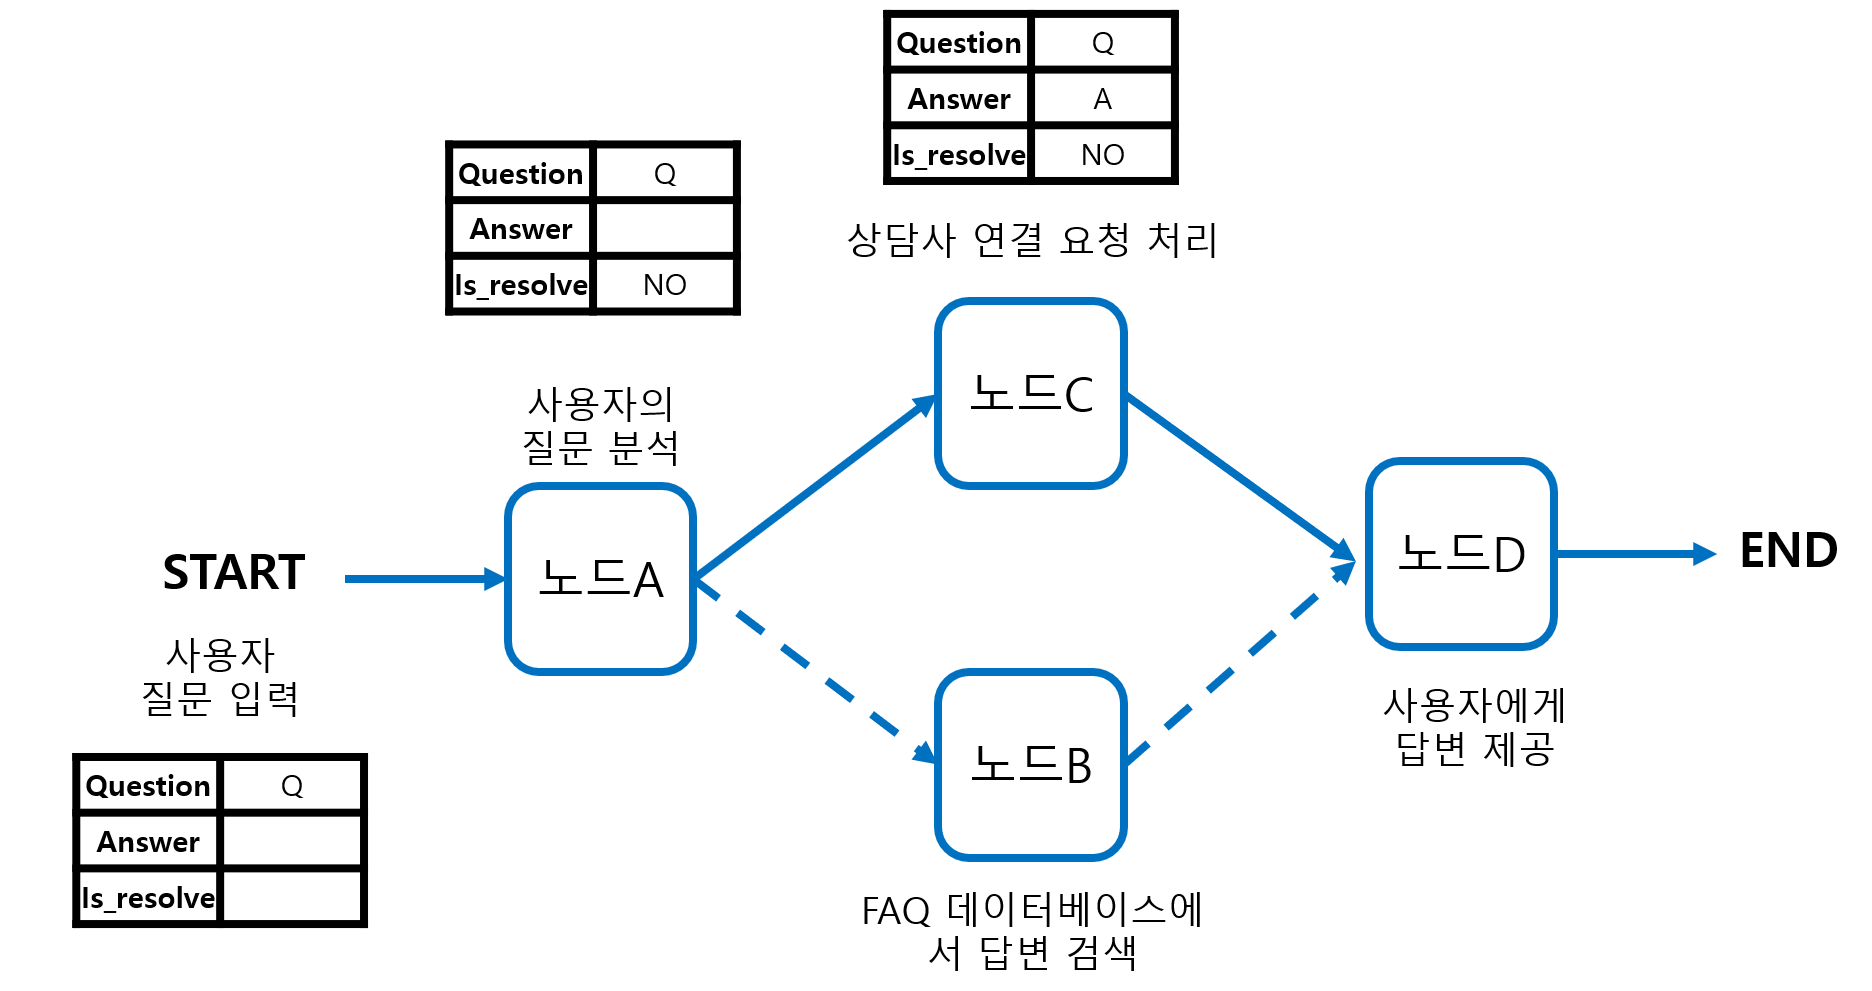

### 1. 간단한 Graph 구축

In [ ]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict

class State(TypedDict):
    text: str
    extra_field: int


In [ ]:
def node(state: State):

    return {"text": state['text'] + "######추가된 텍스트#####", "extra_field": 10}

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import StateGraph, START, END

# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("node", node)

# connect nodes
builder.add_edge(START, "node")
builder.add_edge("node", END)

# compile the graph
graph = builder.compile()

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

graph 실행을 위해 graph.invoke 함수에 state의 초기값을 넣어줍니다.

In [ ]:
graph.invoke({"text" : "안녕!"})

### Rounting을 활용한 조건부 Graph 구축


workflow에서 Routing은 매우 중요합니다. *Routing*(라우팅) 은 특정 입력에 따라 서로 다른 경로를 선택하여 실행 흐름을 제어하는 기능입니다. 이를 통해 사용자의 입력이나 특정 조건에 따라 서로 다른 노드를 실행할 수 있습니다.

In [ ]:
class State(TypedDict):
    input: str
    decision: str
    output: str

In [ ]:
# 노드를 정의합니다!
import random

def decision_maker(state: State):
    state['decision'] = random.choice(['story', 'joke', 'poem'])
    return state

def node_story(state: State):
    """Write a story"""

    result = state['input'] + "에 대한 스토리를 작성한다."
    return {"output": result}


def node_joke(state: State):
    """Write a joke"""

    result = state['input'] + "에 대한 농담을 작성한다."
    return {"output": result}


def node_poem(state: State):
    """Write a poem"""

    result = state['input'] + "에 대한 시를 작성한다."
    return {"output": result}

In [ ]:
# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "story"
    elif state["decision"] == "joke":
        return "joke"
    elif state["decision"] == "poem":
        return "poem"

이제 노드를 연결해봅시다. decision_maker에서 조건에 따라 story, joke, poem 노드로 이동하도록 할 것입니다.

In [ ]:
# Build workflow
router_builder = StateGraph(State)

In [ ]:
# Add nodes
router_builder.add_node("decision_maker", decision_maker)
router_builder.add_node("node_story", node_story)
router_builder.add_node("node_joke", node_joke)
router_builder.add_node("node_poem", node_poem)


# Add edges to connect nodes
router_builder.add_edge(START, "decision_maker")
router_builder.add_conditional_edges(
    "decision_maker",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "story": "node_story",
        "joke": "node_joke",
        "poem": "node_poem",
    },
)
router_builder.add_edge("node_story", END)
router_builder.add_edge("node_joke", END)
router_builder.add_edge("node_poem", END)

# compile the graph
graph = router_builder.compile()

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

조건에 따라 다른 노드가 실행되는 것을 확인할 수 있다.

(이번 코드에서의 조건은 확률에 따라 결정되는 decision 상태)

In [ ]:
for i in range(10):
    result = graph.invoke({"input" : "어떤 이야기"})
    print(result)

### Chatbot으로 변형

In [ ]:
from langchain_openai import ChatOpenAI

# OpenAI의 ChatOpenAI 모델(GPT-4o)을 사용하여 LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini")  # 언어 모델을 gpt-4o로 설정

Chatbot에서는 state에서 대화 이력(Chat history)를 다뤄야 합니다. LangGraph에서는 상태 정보에 대화 이력을 효율적으로 쌓기 위한 기능을 제공합니다. 아래에서 messages 항목을 정의하는 방식을 자세히 살펴봅니다.

In [ ]:
from langchain_core.messages import AnyMessage, AIMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# 아래와 같이 messages 항목을 사전 빌드된 함수인 add_messages로 annotated하면, 목록이 업데이트될 때 덮어쓰지 않고 새롭게 추가됩니다. 이 기능을 알아두는게 매우 중요합니다!!
class State(TypedDict):
    messages: Annotated[list, add_messages]
    extra_field: int

In [ ]:
def chatbot(state: State):
    return {"messages" : llm.invoke(state["messages"])}

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import StateGraph, START, END

# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("chatbot", chatbot)

# connect nodes
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# compile the graph
graph = builder.compile()

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

result = graph.invoke({"messages": [HumanMessage("안녕")]})

결과 보기

In [ ]:
result

In [ ]:
for message in result["messages"]:
    message.pretty_print()

In [ ]:
result = graph.invoke({"messages" : result["messages"] + [HumanMessage("chat template이 뭔지 설명해줘.")]})

In [ ]:
for message in result["messages"]:
    message.pretty_print()

#### Chatbot과 대화해보기

자유롭게 대화해보세요!

"quit", "exit", "q", "종료", "대화종료"으로 대화를 종료할 수 있습니다.

In [ ]:
from langchain_core.messages import HumanMessage

# 대화 기록을 저장할 리스트
conversation_history = []

def chat_with_bot():
    global conversation_history

    print("\n챗봇과 대화를 시작합니다. 'exit'을 입력하면 종료됩니다.\n")

    while True:
        user_input = input("사용자: ")
        if user_input.lower() == "exit":
            print("\n대화를 종료합니다.")
            break

        # 사용자 입력을 HumanMessage로 변환하여 대화 기록에 추가
        conversation_history.append(HumanMessage(user_input))

        # 챗봇 호출
        result = graph.invoke({"messages": conversation_history})

        # 챗봇 응답을 대화 기록에 추가
        conversation_history = result["messages"]

        # 챗봇 응답 출력
        ai_response = conversation_history[-1].content
        print(f"챗봇: {ai_response}\n")

# 챗봇 실행
chat_with_bot()

# Tool과 연결하여 Chatbot 강화하기

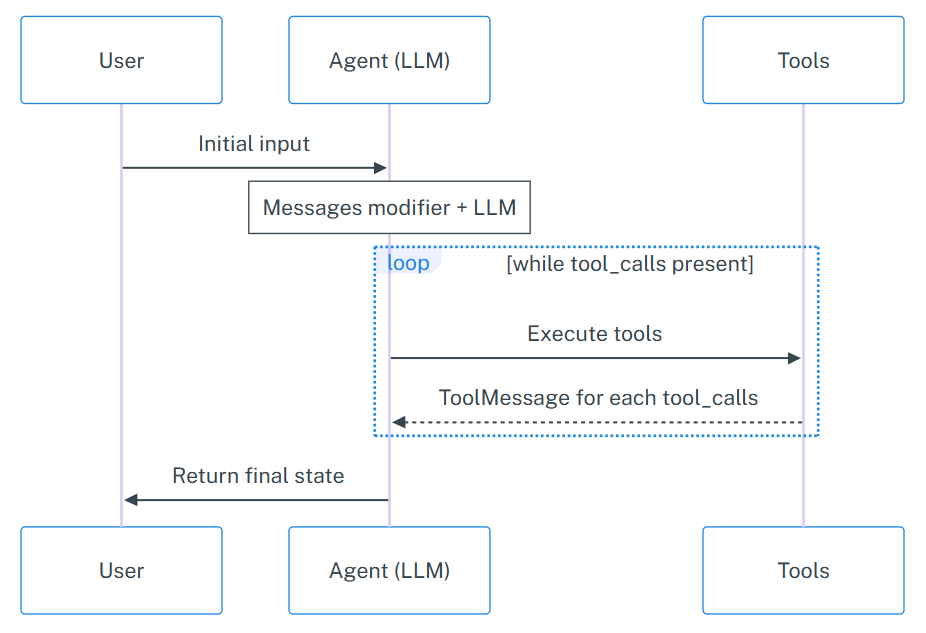

예를 들어, web 검색을 지원하는 외부 api인 Tavily를 tool로 사용해보겠습니다.

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

websearch_api = TavilySearchResults(max_results=3)
websearch_api.invoke("버팀목 대출 소득 기준")

llm의 bind_tools 기능을 통해 tools들을 연결할 수 있습니다.

In [ ]:
from langchain_openai import ChatOpenAI

# OpenAI의 ChatOpenAI 모델(GPT-4o)을 사용하여 LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini")  # 언어 모델을 gpt-4o로 설정

tools = [websearch_api]
llm_with_tools = llm.bind_tools(tools)

#### function calling 작동

In [ ]:
llm_with_tools.invoke("버팀목 대출 소득 기준을 알려주세요.")

In [ ]:
from langchain_core.messages import AnyMessage, AIMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition  # 도구 호출 조건을 확인하는 조건부 로직
from langgraph.prebuilt import ToolNode  # 도구 노드를 정의하는 미리 빌드된 클래스
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages] # 사전 빌드된 함수 덕분에 messages는 기존 목록을 덮어쓰지 않고 새롭게 추가됩니다.


def chatbot(state: State):
    return {"messages" : llm_with_tools.invoke(state["messages"])}


# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

# connect nodes
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

# compile the graph
graph = builder.compile()

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke({"messages": [HumanMessage("버팀목 대출의 소득 기준을 알려줘.")]})

In [ ]:
for message in result["messages"]:
    message.pretty_print()